In [3]:
import sys
from pathlib import Path

# Adds the parent directory (project root) to the Python path
sys.path.append(str(Path.cwd().parent))

Recording... make some noise
dtype: float32
shape: (132300,)
min/max: -0.9958 / 0.9152
Audio: [ 0.0000000e+00  0.0000000e+00 -3.0517578e-05 ... -8.8256836e-02
 -7.1289062e-02 -5.4138184e-02]
Saved recording to sound_testing/sounddevice_test_recording.wav


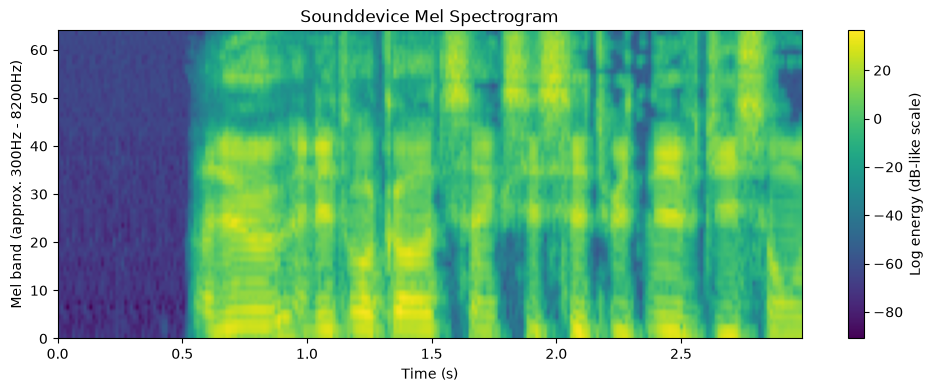

<Axes: title={'center': 'Sounddevice Mel Spectrogram'}, xlabel='Time (s)', ylabel='Mel band (approx. 300Hz - 8200Hz)'>

In [8]:
import sounddevice as sd
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from features.mel_spectogram_generator import MelSpectrogramGen


def plot_mel_spectrogram(
    mel_spec: np.ndarray,
    gen,
    title: str = "Mel Spectrogram",
    ax=None,
):
    sr = gen.sr
    hop_length = gen.hop_length
    low_hz = gen.low_hz
    high_hz = gen.high_hz

    # --- Step 2: figure out the axis ranges ---
    n_mels, n_frames = mel_spec.shape

    # X-axis: convert "frame index" into actual seconds. Each frame
    # represents `hop_length` audio samples, and there are `sr` samples
    # per second, so: seconds_per_frame = hop_length / sr.
    duration_s = n_frames * hop_length / sr

    # --- Step 3: create the figure/axes if the caller didn't pass one in ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    img = ax.imshow(
        mel_spec,
        origin="lower",
        aspect="auto",
        extent=[0, duration_s, 0, n_mels],
        cmap="viridis",
    )

    # --- Step 5: label the axes ---
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"Mel band (approx. {low_hz:.0f}Hz - {high_hz:.0f}Hz)")
    ax.set_title(title)

    # --- Step 6: add a colorbar so viewers know what the colors mean ---
    # The values in mel_spec are in a log/decibel-like scale (from
    # generate_mel_spectogram's log10 step), so we label it as such.
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label("Log energy (dB-like scale)")

    plt.show()

    return ax

sr = 44100
duration_s = 3
output_path = "sound_testing/sounddevice_test_recording.wav"

print("Recording... make some noise")
recording = sd.rec(int(duration_s * sr), samplerate=sr, channels=1, dtype='float32')
sd.wait()  # blocks until the recording finishes

audio_1d = recording[:, 0]
print(f"dtype: {audio_1d.dtype}")
print(f"shape: {audio_1d.shape}")
print(f"min/max: {audio_1d.min():.4f} / {audio_1d.max():.4f}")
print(f"Audio: {audio_1d}")

# Save the recorded audio to a WAV file, at the same sample rate it was captured at.
sf.write(output_path, audio_1d, sr)
print(f"Saved recording to {output_path}")
# Generate spectrogram
gen = MelSpectrogramGen.from_config()
mel_spec = gen.generate_mel_spectrogram(audio_1d)

plot_mel_spectrogram(mel_spec, gen, title="Sounddevice Mel Spectrogram")

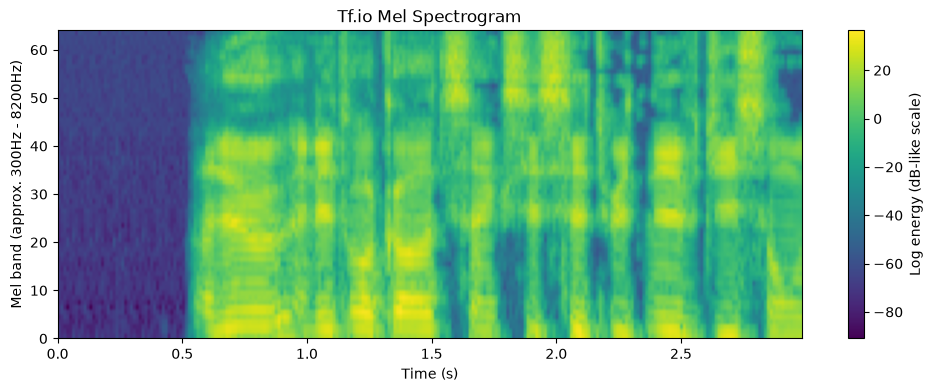

<Axes: title={'center': 'Tf.io Mel Spectrogram'}, xlabel='Time (s)', ylabel='Mel band (approx. 300Hz - 8200Hz)'>

In [11]:
import tensorflow as tf

FILE_PATH = r"C:\University\Student_Teams\BIOM\Real_Time_Capuchin_Classifier\research\sound_testing\sounddevice_test_recording.wav"

raw = tf.io.read_file(FILE_PATH)
audio, sr = tf.audio.decode_wav(raw)

audio = tf.squeeze(audio, axis=1).numpy()

tf_mel_spec = gen.generate_mel_spectrogram(audio)

plot_mel_spectrogram(tf_mel_spec, gen, title="Tf.io Mel Spectrogram")

In [12]:
diff = np.abs(mel_spec - tf_mel_spec)
print(f"max diff: {diff.max():.6f}, mean diff: {diff.mean():.6f}")

max diff: 0.000000, mean diff: 0.000000
